# College Out-Degree Correlation Analysis

Pearson correlations between `n_hs_visited` (out-degree) and college characteristics for 2019 and 2023.

**Steps:**
1. Compute `n_states_visited` (unique HS states per college per year) from `final_data_v4_filtered.csv` and add to `college_out_degree.csv`
2. Encode categorical columns
3. Plot correlation bar chart

**Encoding applied before correlating:**
- `col_inst_control` → `is_public` (1 = public, 0 = private), `is_forprofit` (1 = for-profit, 0 = otherwise)
- `col_inst_size` → negative sentinel values (−1, −2) treated as NaN; kept as ordinal (1–5)
- `col_type` excluded — collinear with `col_inst_control`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

from pathlib import Path
DATA_DIR = Path.cwd() / 'data'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / 'data'

cod = pd.read_csv(DATA_DIR / 'college_out_degree.csv')
print('college_out_degree shape:', cod.shape)
cod.head(2)

college_out_degree shape: (5168, 21)


,college_id,year,n_hs_visited,col_name,col_city,col_st,col_zip,col_ctyname,col_ctyfips,col_type,...,col_inst_size,col_endow_total,col_endow_per_fte,col_number_applied,col_number_admitted,col_number_enrolled_total,col_enrollment_rate,col_acceptance_rate,col_tuition_published,col_tuition_fees_ft
0,100654,2019,23,ALABAMA A & M UNIVERSITY,NORMAL,AL,35762.0,MADISON,1089.0,1.0,...,3.0,NaN,NaN,9579.0,8789.0,1710.0,0.194561,0.917528,17220.0,18634.0
1,100663,2019,235,UNIVERSITY OF ALABAMA AT BIRMINGHAM,BIRMINGHAM,AL,35294.0,JEFFERSON,1073.0,1.0,...,5.0,NaN,NaN,8298.0,6112.0,2346.0,0.383835,0.736563,20400.0,20400.0


## Add n_states_visited

In [2]:
visits = pd.read_csv(
    DATA_DIR / 'final_data_v4_filtered.csv',
    usecols=['college_id', 'cycle', 'hs_id', 'hs_state'],
    low_memory=False,
)

states_by_year = []
for yr in [2019, 2023]:
    sub = visits[visits['cycle'] == yr].copy()
    n_states = (
        sub.drop_duplicates(subset=['college_id', 'hs_state'])
           .groupby('college_id')
           .size()
           .reset_index(name='n_states_visited')
    )
    n_states['year'] = yr
    states_by_year.append(n_states)

states_df = pd.concat(states_by_year, ignore_index=True)
print('States df shape:', states_df.shape)
print(states_df.groupby('year')['n_states_visited'].describe().round(1))

States df shape: (5168, 3)
       count  mean  std  min  25%  50%   75%   max
year                                              
2019  2632.0   8.8  8.4  1.0  3.0  6.0  12.0  49.0
2023  2536.0   5.8  5.5  1.0  2.0  4.0   8.0  37.0


In [3]:
cod = cod.merge(states_df, on=['college_id', 'year'], how='left')

# Insert n_states_visited right after n_hs_visited
cols = cod.columns.tolist()
cols.remove('n_states_visited')
idx = cols.index('n_hs_visited') + 1
cols.insert(idx, 'n_states_visited')
cod = cod[cols]

print('Missing n_states_visited:', cod['n_states_visited'].isna().sum())
print('college_out_degree shape after merge:', cod.shape)
cod.head(2)

Missing n_states_visited: 0
college_out_degree shape after merge: (5168, 22)


,college_id,year,n_hs_visited,n_states_visited,col_name,col_city,col_st,col_zip,col_ctyname,col_ctyfips,...,col_inst_size,col_endow_total,col_endow_per_fte,col_number_applied,col_number_admitted,col_number_enrolled_total,col_enrollment_rate,col_acceptance_rate,col_tuition_published,col_tuition_fees_ft
0,100654,2019,23,8,ALABAMA A & M UNIVERSITY,NORMAL,AL,35762.0,MADISON,1089.0,...,3.0,NaN,NaN,9579.0,8789.0,1710.0,0.194561,0.917528,17220.0,18634.0
1,100663,2019,235,34,UNIVERSITY OF ALABAMA AT BIRMINGHAM,BIRMINGHAM,AL,35294.0,JEFFERSON,1073.0,...,5.0,NaN,NaN,8298.0,6112.0,2346.0,0.383835,0.736563,20400.0,20400.0


In [4]:
cod.to_csv(DATA_DIR / 'college_out_degree.csv', index=False)
print(f'Saved college_out_degree.csv  ({len(cod):,} rows, {len(cod.columns)} columns)')

Saved college_out_degree.csv  (5,168 rows, 22 columns)


## Correlations with Out-Degree — 2019 and 2023

In [5]:
def encode_college(df_in):
    d = df_in.copy()

    # inst_control: 1=public, 2=private nonprofit, 3=private for-profit
    d['is_public']    = np.where(d['col_inst_control'] == 1, 1.0,
                        np.where(d['col_inst_control'].isna(), np.nan, 0.0))
    d['is_forprofit'] = np.where(d['col_inst_control'] == 3, 1.0,
                        np.where(d['col_inst_control'].isna(), np.nan, 0.0))

    # inst_size: ordinal 1–5; negative sentinels → NaN
    d['col_inst_size'] = d['col_inst_size'].where(d['col_inst_size'] > 0, np.nan)

    return d

cod_enc = encode_college(cod)
print('Encoding done.')

Encoding done.


In [6]:
corr_cols = [
    'n_hs_visited',
    # control & size
    'is_public',
    'is_forprofit',
    'col_inst_size',
    # endowment
    'col_endow_total',
    'col_endow_per_fte',
    # admissions
    'col_number_applied',
    'col_number_admitted',
    'col_number_enrolled_total',
    'col_acceptance_rate',
    'col_enrollment_rate',
    # tuition
    'col_tuition_published',
    'col_tuition_fees_ft',
]

labels = {
    'n_hs_visited':               'Out-Degree (# HS Visited)',
    'is_public':                  'Is Public',
    'is_forprofit':               'Is For-Profit',
    'col_inst_size':              'Institution Size (ordinal)',
    'col_endow_total':            'Endowment Total',
    'col_endow_per_fte':          'Endowment per FTE',
    'col_number_applied':         '# Applied',
    'col_number_admitted':        '# Admitted',
    'col_number_enrolled_total':  '# Enrolled',
    'col_acceptance_rate':        'Acceptance Rate',
    'col_enrollment_rate':        'Enrollment Rate',
    'col_tuition_published':      'Published Tuition',
    'col_tuition_fees_ft':        'Tuition + Fees (FT)',
}

predictor_cols = [c for c in corr_cols if c != 'n_hs_visited']

corr_rows = {}
for yr in [2019, 2023]:
    sub = cod_enc[cod_enc['year'] == yr][corr_cols]
    corr_rows[yr] = sub.corrwith(sub['n_hs_visited']).drop('n_hs_visited')

corr_df = pd.DataFrame(corr_rows).rename(columns={2019: '2019', 2023: '2023'})
corr_df.index = [labels[c] for c in corr_df.index]
corr_df['avg'] = corr_df.mean(axis=1)
corr_df = corr_df.sort_values('avg', ascending=False)

print('Pearson r with Out-Degree (# HS Visited):')
print(corr_df[['2019', '2023']].round(4).to_string())

Pearson r with Out-Degree (# HS Visited):
                              2019    2023
# Enrolled                  0.6092  0.6873
# Applied                   0.6543  0.5980
Institution Size (ordinal)  0.5651  0.6130
# Admitted                  0.5295  0.5820
Endowment Total             0.4840  0.3563
Is Public                   0.2084  0.2734
Tuition + Fees (FT)         0.2729  0.1890
Published Tuition           0.2511  0.1684
Endowment per FTE           0.1045  0.0759
Enrollment Rate             0.0646  0.0497
Is For-Profit              -0.0958 -0.1398
Acceptance Rate            -0.2502 -0.1724


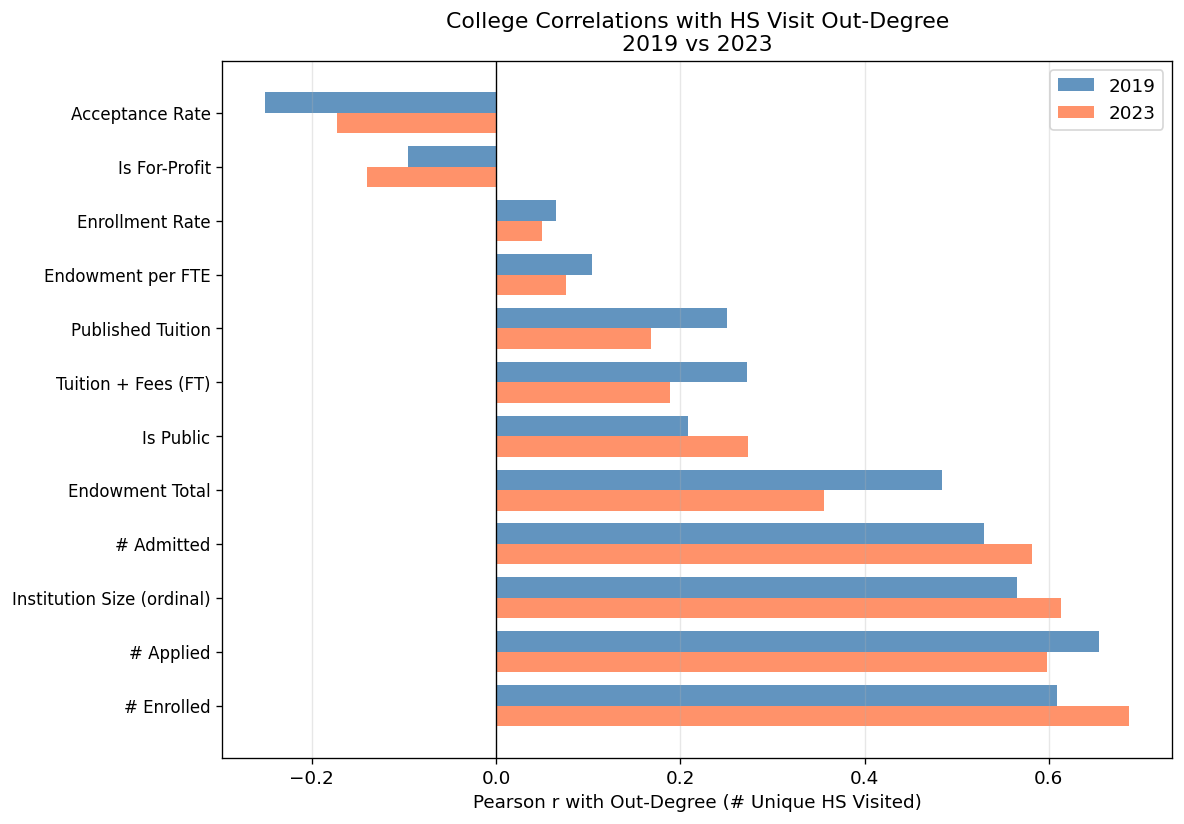

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

x = np.arange(len(corr_df))
width = 0.38

ax.barh(x + width/2, corr_df['2019'], width, label='2019', color='steelblue', alpha=0.85)
ax.barh(x - width/2, corr_df['2023'], width, label='2023', color='coral',     alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(corr_df.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with Out-Degree (# Unique HS Visited)')
ax.set_title('College Correlations with HS Visit Out-Degree\n2019 vs 2023')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/college_outdegree_corr_bars.png', bbox_inches='tight')
plt.show()

In [9]:
corr_df[['2019', '2023']].to_csv(DATA_DIR / 'college_outdegree_corr.csv')
print('Saved college_outdegree_corr.csv')

Saved college_outdegree_corr.csv


## Scatter Plots — Key Relationships

- **Scatter plots (4 × 2 grid):** Top continuous predictors — # Enrolled, # Applied, Endowment Total, Acceptance Rate — each shown for 2019 and 2023 with an OLS trendline and Pearson r.
- **Box plots:** Institution control (public / private nonprofit / for-profit) and institution size — distribution of out-degree by group for both years.

y-axis is `log1p(n_hs_visited)` throughout to handle right skew. Enrollment, applied, and endowment are also log-transformed on x.

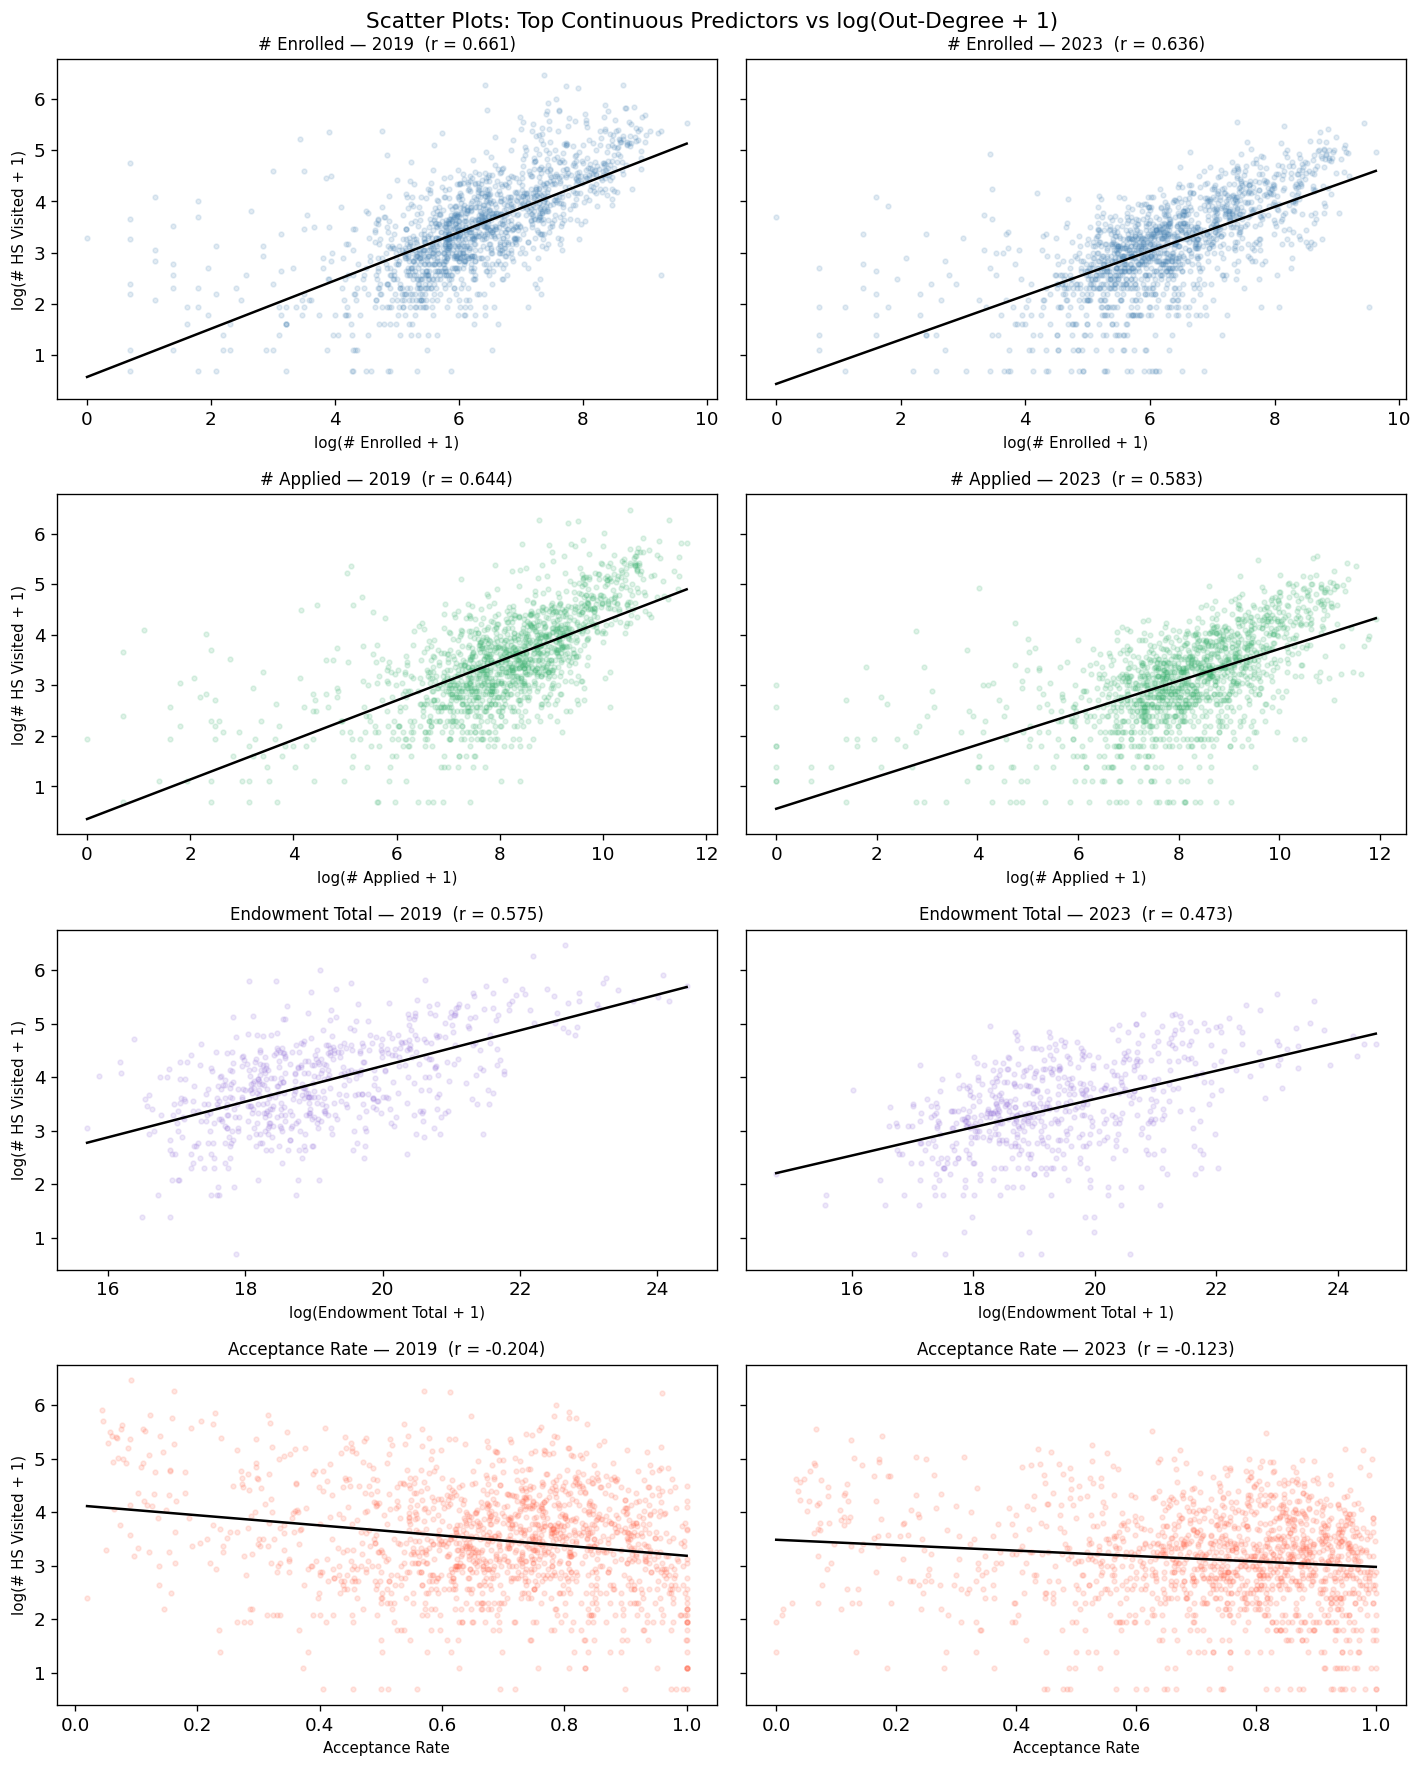

In [10]:
continuous_vars = [
    ('col_number_enrolled_total', '# Enrolled',      'steelblue',      True),
    ('col_number_applied',        '# Applied',        'mediumseagreen', True),
    ('col_endow_total',           'Endowment Total',  'mediumpurple',   True),
    ('col_acceptance_rate',       'Acceptance Rate',  'tomato',         False),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 15), sharey='row')

for row, (col, lbl, color, log_x) in enumerate(continuous_vars):
    for col_idx, yr in enumerate([2019, 2023]):
        ax = axes[row, col_idx]
        sub = cod_enc[cod_enc['year'] == yr][['n_hs_visited', col]].dropna()

        x_raw = sub[col].values
        x = np.log1p(x_raw) if log_x else x_raw
        y = np.log1p(sub['n_hs_visited'].values)

        ax.scatter(x, y, alpha=0.15, s=8, color=color, rasterized=True)
        m, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 200)
        ax.plot(xr, m * xr + b, color='black', linewidth=1.5)

        r = np.corrcoef(x, y)[0, 1]
        x_label = f'log({lbl} + 1)' if log_x else lbl
        ax.set_title(f'{lbl} — {yr}  (r = {r:.3f})', fontsize=10)
        ax.set_xlabel(x_label, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel('log(# HS Visited + 1)', fontsize=9)

fig.suptitle('Scatter Plots: Top Continuous Predictors vs log(Out-Degree + 1)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/college_outdegree_scatter_continuous.png', bbox_inches='tight')
plt.show()

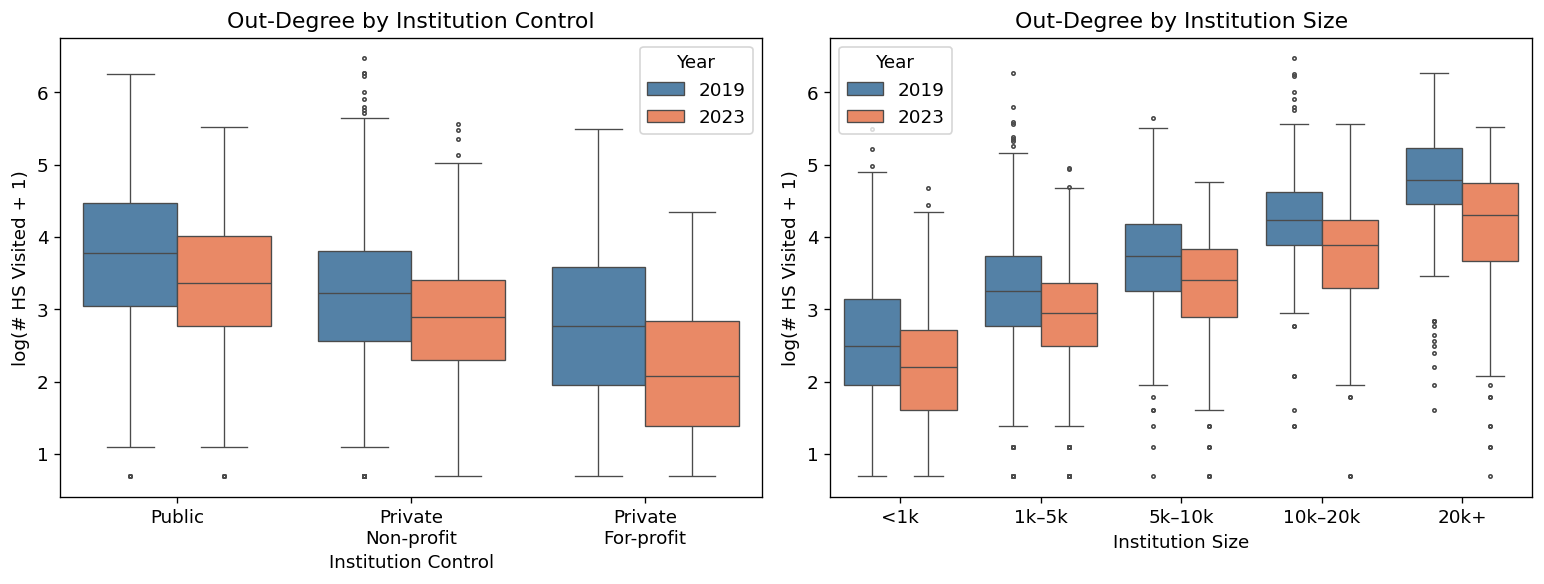

In [11]:
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Institution control
control_map = {1.0: 'Public', 2.0: 'Private\nNon-profit', 3.0: 'Private\nFor-profit'}
plot_ctrl = cod_enc[cod_enc['col_inst_control'].notna()].copy()
plot_ctrl['inst_control_label'] = plot_ctrl['col_inst_control'].map(control_map)
plot_ctrl['log_outdegree'] = np.log1p(plot_ctrl['n_hs_visited'])
plot_ctrl['year'] = plot_ctrl['year'].astype(str)
sns.boxplot(
    data=plot_ctrl, x='inst_control_label', y='log_outdegree', hue='year',
    order=['Public', 'Private\nNon-profit', 'Private\nFor-profit'],
    palette={'2019': 'steelblue', '2023': 'coral'},
    fliersize=2, linewidth=0.8, ax=ax1,
)
ax1.set_xlabel('Institution Control')
ax1.set_ylabel('log(# HS Visited + 1)')
ax1.set_title('Out-Degree by Institution Control')
ax1.legend(title='Year')

# Institution size (ordinal 1–5)
size_map = {1.0: '<1k', 2.0: '1k–5k', 3.0: '5k–10k', 4.0: '10k–20k', 5.0: '20k+'}
plot_size = cod_enc[cod_enc['col_inst_size'].notna()].copy()
plot_size['inst_size_label'] = plot_size['col_inst_size'].map(size_map)
plot_size['log_outdegree'] = np.log1p(plot_size['n_hs_visited'])
plot_size['year'] = plot_size['year'].astype(str)
sns.boxplot(
    data=plot_size, x='inst_size_label', y='log_outdegree', hue='year',
    order=['<1k', '1k–5k', '5k–10k', '10k–20k', '20k+'],
    palette={'2019': 'steelblue', '2023': 'coral'},
    fliersize=2, linewidth=0.8, ax=ax2,
)
ax2.set_xlabel('Institution Size')
ax2.set_ylabel('log(# HS Visited + 1)')
ax2.set_title('Out-Degree by Institution Size')
ax2.legend(title='Year')

plt.tight_layout()
plt.savefig('../data/college_outdegree_boxplots_categorical.png', bbox_inches='tight')
plt.show()

## Correlations with States Visited — 2019 and 2023

Pearson r with States Visited:
                              2019    2023
# Enrolled                  0.6146  0.6064
Institution Size (ordinal)  0.5914  0.5739
# Applied                   0.6221  0.5365
# Admitted                  0.5482  0.5233
Endowment Total             0.4132  0.3520
Tuition + Fees (FT)         0.3156  0.2482
Published Tuition           0.2943  0.2321
Is Public                   0.2218  0.2223
Endowment per FTE           0.0837  0.0605
Enrollment Rate             0.0386  0.0470
Is For-Profit              -0.0968 -0.1597
Acceptance Rate            -0.2374 -0.1909


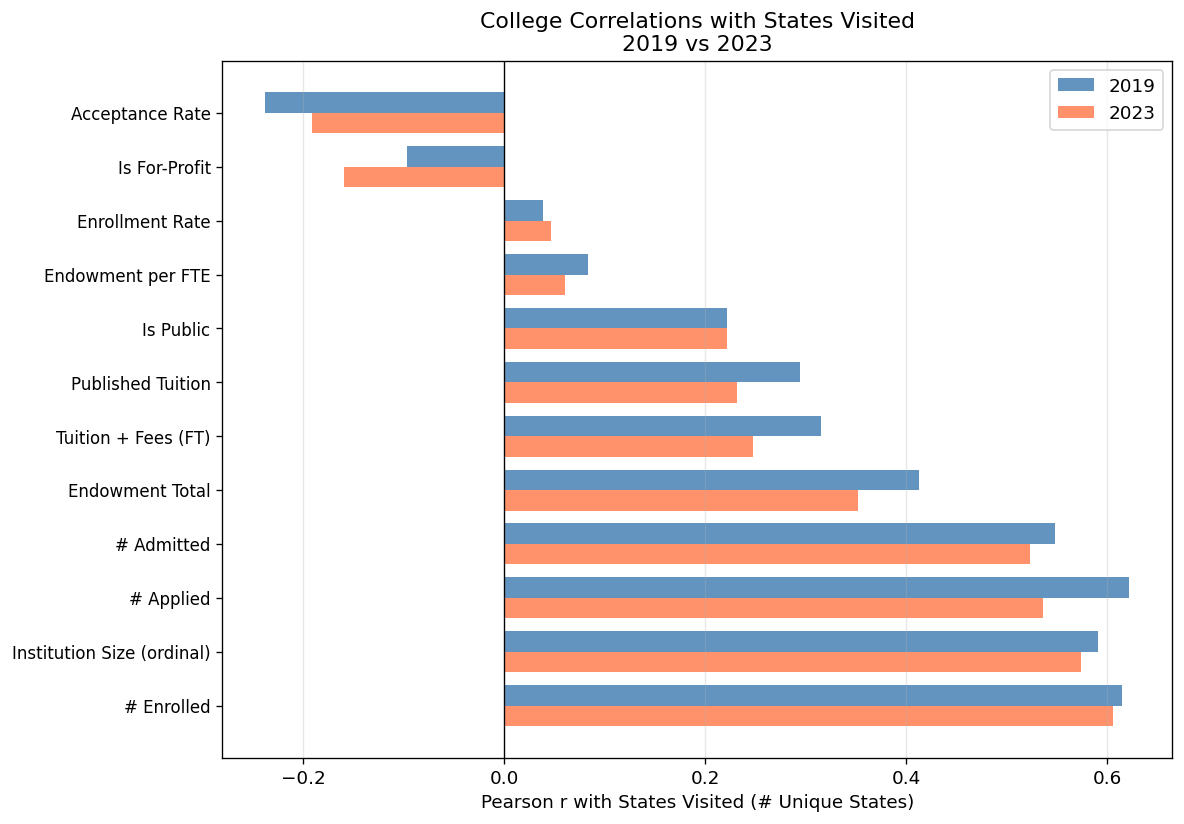

Saved college_states_visited_corr.csv


In [12]:
states_corr_cols = [
    'n_states_visited',
    'is_public',
    'is_forprofit',
    'col_inst_size',
    'col_endow_total',
    'col_endow_per_fte',
    'col_number_applied',
    'col_number_admitted',
    'col_number_enrolled_total',
    'col_acceptance_rate',
    'col_enrollment_rate',
    'col_tuition_published',
    'col_tuition_fees_ft',
]

states_corr_rows = {}
for yr in [2019, 2023]:
    sub = cod_enc[cod_enc['year'] == yr][states_corr_cols]
    states_corr_rows[yr] = sub.corrwith(sub['n_states_visited']).drop('n_states_visited')

states_corr_df = pd.DataFrame(states_corr_rows).rename(columns={2019: '2019', 2023: '2023'})
states_corr_df.index = [labels[c] for c in states_corr_df.index]
states_corr_df['avg'] = states_corr_df.mean(axis=1)
states_corr_df = states_corr_df.sort_values('avg', ascending=False)

print('Pearson r with States Visited:')
print(states_corr_df[['2019', '2023']].round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))

x = np.arange(len(states_corr_df))
width = 0.38

ax.barh(x + width/2, states_corr_df['2019'], width, label='2019', color='steelblue', alpha=0.85)
ax.barh(x - width/2, states_corr_df['2023'], width, label='2023', color='coral',     alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(states_corr_df.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with States Visited (# Unique States)')
ax.set_title('College Correlations with States Visited\n2019 vs 2023')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/college_states_visited_corr_bars.png', bbox_inches='tight')
plt.show()

states_corr_df[['2019', '2023']].to_csv(DATA_DIR / 'college_states_visited_corr.csv')
print('Saved college_states_visited_corr.csv')

In [13]:
top20 = (
    cod
    .sort_values('n_hs_visited', ascending=False)
    .groupby('year', group_keys=False)
    .head(20)
    .sort_values(['year', 'n_hs_visited'], ascending=[True, False])
)

out_path = DATA_DIR / 'college_outdegree_top20.csv'
top20.to_csv(out_path, index=False)
print(f'Saved {out_path}  ({len(top20)} rows)')
top20[['year', 'col_name', 'col_st', 'n_hs_visited', 'n_states_visited']]

Saved /Users/bryceclement/Desktop/c2i/data/college_outdegree_top20.csv  (40 rows)


,year,col_name,col_st,n_hs_visited,n_states_visited
1474,2019,VANDERBILT UNIVERSITY,TN,644,45
345,2019,SCHOOL OF THE ART INSTITUTE OF CHICAGO,IL,528,42
997,2019,NEW YORK UNIVERSITY,NY,525,46
197,2019,METROPOLITAN STATE UNIVERSITY OF DENVER,CO,516,49
322,2019,SAVANNAH COLLEGE OF ART AND DESIGN,GA,502,43
1002,2019,PACE UNIVERSITY,NY,405,45
2244,2019,MERCY COLLEGE - MANHATTAN CAMPUS,NY,400,40
1696,2019,STANFORD UNIVERSITY,CA,368,37
431,2019,INDIANA UNIVERSITY-PURDUE UNIVERSITY-INDIANAPOLIS,IN,355,40
712,2019,UNIVERSITY OF MICHIGAN-ANN ARBOR,MI,345,40
